In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:

try:

    df = pd.read_csv('/Users/eugenio/Documents/Computer_Vision/Ventas 2023-2025 11-03-26 - CSV.csv', sep=';') # Se añadió 'sep=';''

    print("\n¡Base de datos CSV importada con éxito!")
    print("Primeras 5 filas para ver los datos y campos:\n")
    display(df.head())

    print("\nInformación general (columnas, tipos de datos, valores no nulos):\n")
    df.info()

except FileNotFoundError:
    print("Error: El archivo CSV no se encontró. Asegúrate de que la ruta sea correcta.")
    print("Si el archivo está en tu PC, puedes subirlo a Colab (menú lateral > ícono de carpeta > Subir).")
    print("Si el archivo está en Google Drive, asegúrate de haber montado Google Drive y de que la ruta sea correcta.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo CSV: {e}")


¡Base de datos CSV importada con éxito!
Primeras 5 filas para ver los datos y campos:



,FECHA,AÑO,MES,CLIENTES,CODIGO PRODUCTO,CATEGORIA,SUBCATEGORIA,DEMANDA REAL (Q),PRECIO TOTAL,DESCUENTO,DSC %,SUBTOTAL PRODUCTO ANTES DE IMPUESTOS,IVA TOTAL,IVA %,TOTAL PRODUCTO,COSTO TOTAL,GRUPO CLIENTES,TARIFA FACTURA
0,3/4/2023,2023,ABRIL,CL0026,PR1332,ANTIESTRÉS Y PASATIEMPOS,ROMPECABEZAS,1,"$0,75",$-,0%,"$0,75","$0,09",12%,"$0,84","$0,43",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
1,3/4/2023,2023,ABRIL,CL0026,PR0806,ANTIESTRÉS Y PASATIEMPOS,JUEGOS DE MESA,1,"$0,28",$-,0%,"$0,28","$0,03",12%,"$0,31","$0,18",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
2,4/4/2023,2023,ABRIL,CL0053,PR1119,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,60,"$28,20",$-,0%,"$28,20","$3,38",12%,"$31,58","$14,40",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
3,4/4/2023,2023,ABRIL,CL0040,PR1113,ANTIESTRÉS Y PASATIEMPOS,PRODUCTOS ANTIESTRES,12,"$5,64",$-,0%,"$5,64","$0,68",12%,"$6,32","$2,88",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
4,5/4/2023,2023,ABRIL,CL0067,PR0794,ANTIESTRÉS Y PASATIEMPOS,JUEGOS DE MESA,2,"$9,35",$-,0%,"$9,35","$1,12",12%,"$10,47","$5,42",PUBLI EMPRESARIAL,PUBLIEMPRESARIAL



Información general (columnas, tipos de datos, valores no nulos):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68034 entries, 0 to 68033
Data columns (total 18 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   FECHA                                   68034 non-null  object
 1   AÑO                                     68034 non-null  int64 
 2   MES                                     68034 non-null  object
 3   CLIENTES                                68034 non-null  object
 4   CODIGO PRODUCTO                         68034 non-null  object
 5   CATEGORIA                               68034 non-null  object
 6   SUBCATEGORIA                            68034 non-null  object
 7   DEMANDA REAL (Q)                        68034 non-null  int64 
 8    PRECIO TOTAL                           68034 non-null  object
 9    DESCUENTO                              68034 non-null  object
 10  DS

Ahora, convertiremos la columna 'FECHA' al formato de fecha y generaremos el gráfico de la demanda a lo largo del tiempo.

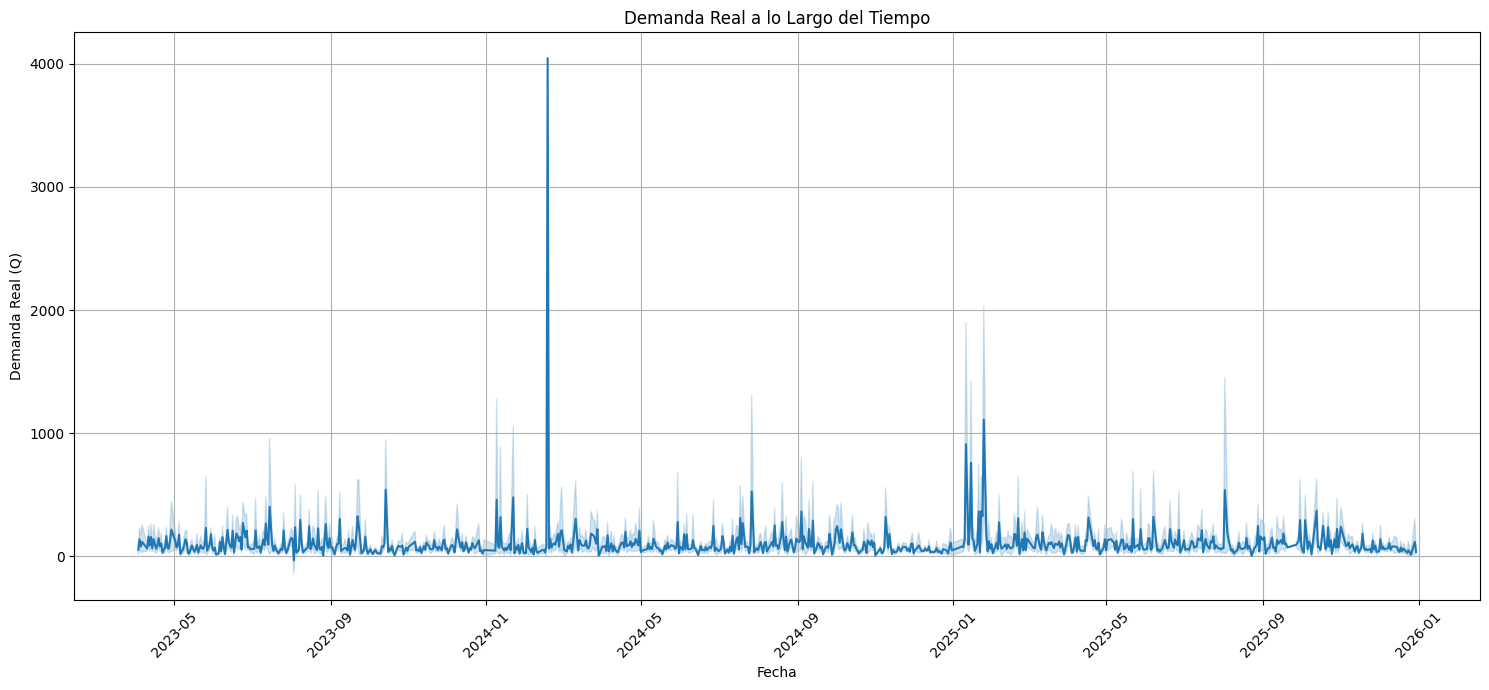

In [6]:
# Asegúrate de que la columna 'FECHA' esté en formato de fecha y hora
# Si tu columna de fecha tiene un formato diferente, es posible que necesites ajustar el argumento 'format'
# Por ejemplo: df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d/%m/%Y')
df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d/%m/%Y')

# Ordenar los datos por fecha para asegurar una visualización correcta de la serie temporal
df = df.sort_values(by='FECHA')

plt.figure(figsize=(15, 7))
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=df)
plt.title('Demanda Real a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.tight_layout()
plt.show()


In [7]:
# Detectar los datos atípicos utilizando el método del rango intercuartílico (IQR)
Q1 = df['DEMANDA REAL (Q)'].quantile(0.25)
Q3 = df['DEMANDA REAL (Q)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['DEMANDA REAL (Q)'] < lower_bound) | (df['DEMANDA REAL (Q)'] > upper_bound)]

# Eliminar los datos atípicos del DataFrame original
df_cleaned = df[(df['DEMANDA REAL (Q)'] >= lower_bound) & (df['DEMANDA REAL (Q)'] <= upper_bound)]


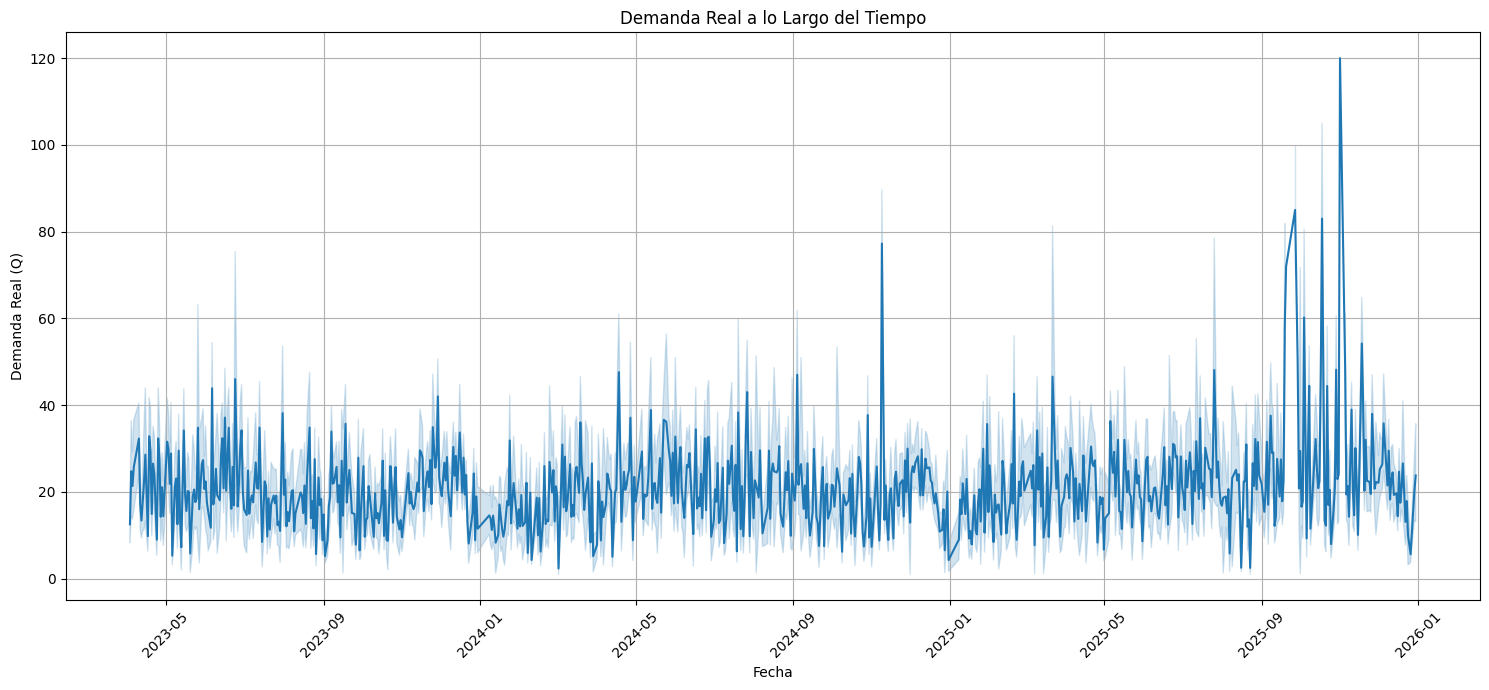

In [8]:

plt.figure(figsize=(15, 7))
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=df_cleaned)
plt.title('Demanda Real a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.tight_layout()
plt.show()

### Segmentación de Datos: Entrenamiento (20%) y Prueba (80%)

Ahora dividiremos nuestro conjunto de datos en dos partes: un conjunto de entrenamiento, que contendrá el 20% de los datos, y un conjunto de prueba, que contendrá el 80% restante. Esto es fundamental para evaluar el rendimiento de cualquier modelo que construyamos, asegurándonos de que no se "sobreajuste" a los datos que ya ha visto.

In [9]:
# Divide la base de datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba) para predicción en tiempo (forecasting temporal)
train_size = int(len(df_cleaned) * 0.8)
train_data = df_cleaned.iloc[:train_size]
test_data = df_cleaned.iloc[train_size:]


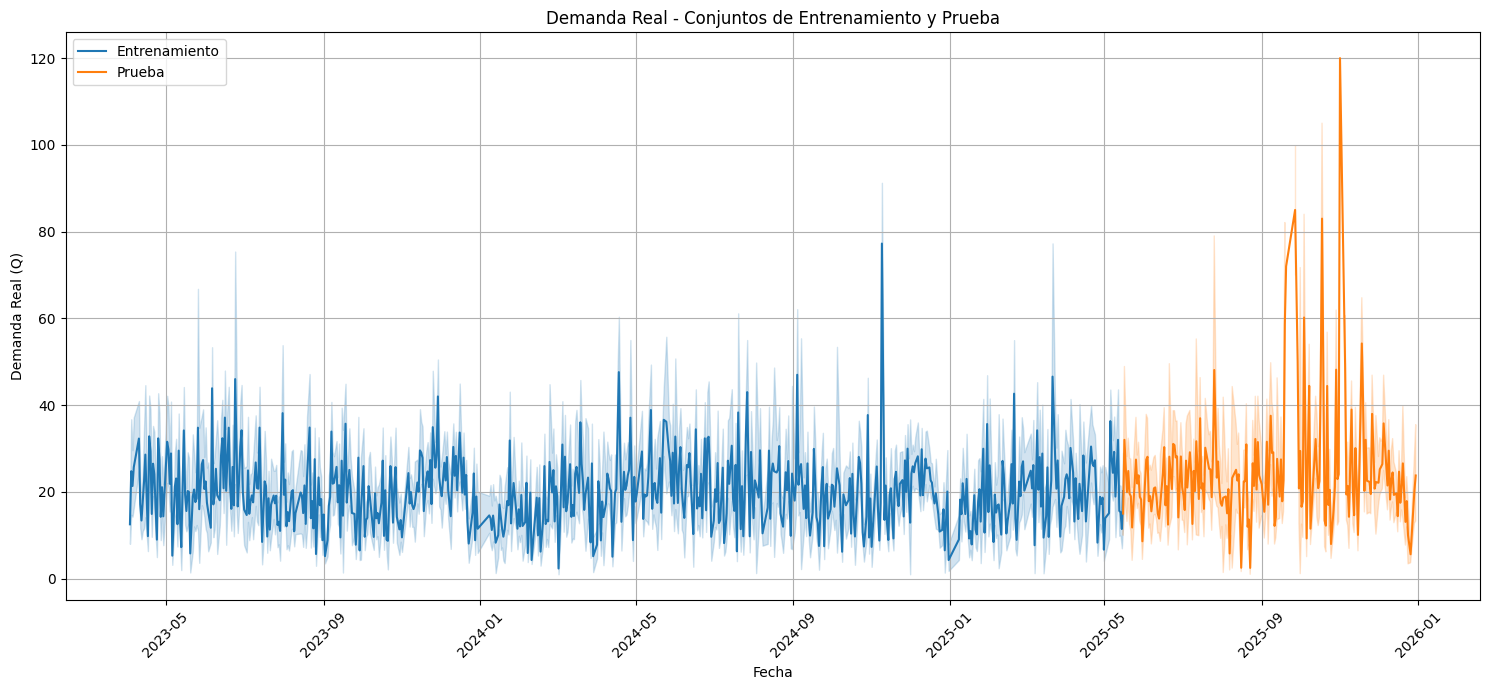

In [10]:
# Plotear los datos de entrenamiento y prueba para visualizar la división
plt.figure(figsize=(15, 7))
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=train_data, label='Entrenamiento')
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=test_data, label='Prueba')
plt.title('Demanda Real - Conjuntos de Entrenamiento y Prueba')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Ajusta un modelo de regresión lineal a los datos de entrenamiento
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# Convertir FECHA a valor numérico (ordinal) para la regresión
train_data = train_data.copy()
test_data = test_data.copy()

train_data['FECHA_NUM'] = train_data['FECHA'].map(pd.Timestamp.toordinal)
test_data['FECHA_NUM'] = test_data['FECHA'].map(pd.Timestamp.toordinal)

In [16]:

model = LinearRegression()
model.fit(train_data[['FECHA_NUM']], train_data['DEMANDA REAL (Q)'])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
# Realiza predicciones en el conjunto de prueba
predictions = model.predict(test_data[['FECHA_NUM']])


In [ ]:

# Evalúa el rendimiento del modelo
mse = mean_squared_error(test_data['DEMANDA REAL (Q)'], predictions)
r2 = r2_score(test_data['DEMANDA REAL (Q)'], predictions)


In [21]:
import numpy as np
# Evalúa el rmse tomando la raíz cuadrada del mse
rmse = np.sqrt(mse)

In [22]:
# Imprime los resultados de la evaluación
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

Error Cuadrático Medio (MSE): 1050.29
Coeficiente de Determinación (R²): -0.01
Raíz del Error Cuadrático Medio (RMSE): 32.41


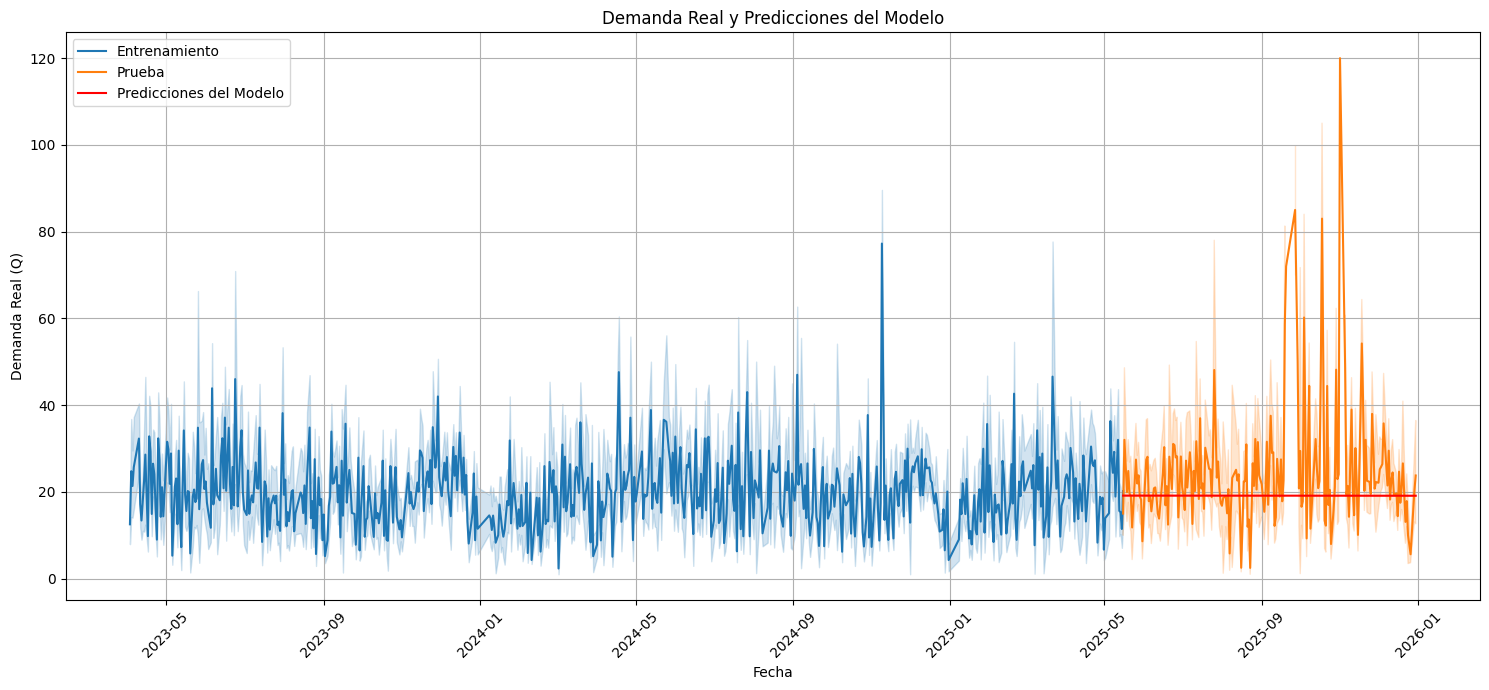

In [25]:
# Grafica la base de datos original, los datos de entrenamiento, los datos de prueba y las predicciones del modelo
plt.figure(figsize=(15, 7))
#sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=df_cleaned, label='Datos Originales')
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=train_data, label='Entrenamiento')
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=test_data, label='Prueba')
sns.lineplot(x=test_data['FECHA'], y=predictions, label='Predicciones del Modelo', color='red')
plt.title('Demanda Real y Predicciones del Modelo')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

# Grafica las predicciones vs los valores reales
plt.figure(figsize=(15, 7))
sns.lineplot(x='FECHA', y='DEMANDA REAL (Q)', data=test_data, label='Valores Reales', color='blue')
plt.plot(test_data['FECHA'], predictions, label='Predicciones', color='red')
plt.title('Predicciones vs Valores Reales')
plt.xlabel('Fecha')
plt.ylabel('Demanda Real (Q)')
plt.grid(True)
plt.xticks(rotation=45) # Rota las etiquetas del eje X para mejor legibilidad
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# Asumiendo que 'DEMANDA REAL (Q)' es la variable objetivo (y) y el resto son características (X)
# Para este ejemplo, estamos dividiendo todo el DataFrame para mantener la estructura.
# En un caso real, podrías separar explícitamente X e y antes de la división.

# Dividimos los datos en 20% para entrenamiento y 80% para prueba
df_train, df_test = train_test_split(df, test_size=0.8, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {df_train.shape[0]} filas")
print(f"Tamaño del conjunto de prueba: {df_test.shape[0]} filas")

print("\nPrimeras 5 filas del conjunto de entrenamiento:\n")
display(df_train.head())

print("\nPrimeras 5 filas del conjunto de prueba:\n")
display(df_test.head())


Tamaño del conjunto de entrenamiento: 13606 filas
Tamaño del conjunto de prueba: 54428 filas

Primeras 5 filas del conjunto de entrenamiento:



,FECHA,AÑO,MES,CLIENTES,CODIGO PRODUCTO,CATEGORIA,SUBCATEGORIA,DEMANDA REAL (Q),PRECIO TOTAL,DESCUENTO,DSC %,SUBTOTAL PRODUCTO ANTES DE IMPUESTOS,IVA TOTAL,IVA %,TOTAL PRODUCTO,COSTO TOTAL,GRUPO CLIENTES,TARIFA FACTURA
64932,2024-10-09,2024,OCTUBRE,CL2178,PR2889,TOMATODOS,TOMATODOS METALICOS,1,"$4,28","$1,71",40%,"$2,57","$0,39",15%,"$2,96","$1,87",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
55101,2025-02-22,2025,FEBRERO,CL2536,PR1842,JARROS,JARROS SUBLIMACIÓN,6,"$6,40","$2,56",40%,"$3,84","$0,58",15%,"$4,42","$2,73",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
27284,2023-12-04,2023,DICIEMBRE,CL0729,PR0230,ESCRITURA,BOLIGRAFOS PLASTICOS,50,"$8,84",$-,0%,"$8,84","$1,06",12%,"$9,90","$5,36",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
54308,2024-11-29,2024,NOVIEMBRE,CL1186,PR1886,JARROS,JARROS SUBLIMACIÓN,1,"$3,15","$1,26",40%,"$1,89","$0,28",15%,"$2,17","$1,30",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
53460,2024-07-18,2024,JULIO,CL1284,PR1842,JARROS,JARROS SUBLIMACIÓN,30,"$32,00","$12,80",40%,"$19,20","$2,88",15%,"$22,08","$13,66",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR



Primeras 5 filas del conjunto de prueba:



,FECHA,AÑO,MES,CLIENTES,CODIGO PRODUCTO,CATEGORIA,SUBCATEGORIA,DEMANDA REAL (Q),PRECIO TOTAL,DESCUENTO,DSC %,SUBTOTAL PRODUCTO ANTES DE IMPUESTOS,IVA TOTAL,IVA %,TOTAL PRODUCTO,COSTO TOTAL,GRUPO CLIENTES,TARIFA FACTURA
65002,2024-10-18,2024,OCTUBRE,CL2805,PR1959,TOMATODOS,TOMATODOS PLASTICOS,4,"$6,47","$2,59",40%,"$3,88","$0,58",15%,"$4,46","$2,50",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
46045,2025-06-30,2025,JUNIO,CL0756,PR2533,ESCRITURA,LAPICES ECOLOGICOS,100,"$13,33","$5,33",40%,"$8,00","$1,20",15%,"$9,20","$5,75",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
57567,2023-05-17,2023,MAYO,CL0642,PR0904,LLAVEROS,LLAVEROS METALICOS,1,"$0,15",$-,0%,"$0,15","$0,02",12%,"$0,17","$0,12",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
45743,2025-06-18,2025,JUNIO,CL3176,PR0141,ESCRITURA,BOLIGRAFOS PLASTICOS,12,"$3,00","$1,20",40%,"$1,80","$0,27",15%,"$2,07","$1,00",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
3191,2025-01-14,2025,ENERO,CL1353,PR0625,BOLSOS Y FUNDAS,FUNDAS DE PAPEL,4,"$1,93","$0,77",40%,"$1,16","$0,17",15%,"$1,33","$0,84",PUBLI DISTRIBUIDOR,PUBLIDISTRIBUIDOR
